Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269 (1.05 KB)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 180 (724.00 B)

Accuracy: 0.6000000238418579
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Predictions:
Predicted: 1 Actual: 1
Predicted: 1 Actual: 0
Predicted: 1 Actual: 1
Predicted: 1 Actual: 0
Predicted: 1 Actual: 1
Predicted: 1 Actual: 0
Predicted: 1 Actual: 1
Predicted: 1 Actual: 0
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1


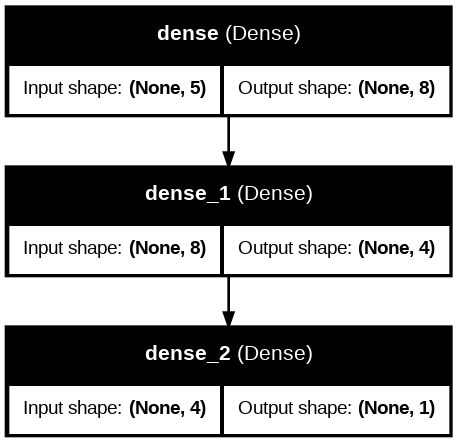

In [1]:
# Aim:
# To design and implement a Neural Network using Keras API
# for Binary Classification and plot the model architecture.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import plot_model
from IPython.display import Image

# Column names:
# CGPA, Aptitude_Score, Projects, Internship, Technical_Score
# Target column: Placed

# Small dataset: 10 rows, 5 input columns, 1 target column
# Example: Student placement prediction
X = np.array([
    [8.5, 90, 2, 1, 85],
    [6.2, 60, 0, 0, 55],
    [7.8, 75, 1, 1, 70],
    [5.5, 50, 0, 0, 45],
    [9.0, 95, 3, 1, 90],
    [6.8, 65, 1, 0, 60],
    [8.0, 80, 2, 1, 78],
    [5.8, 48, 0, 0, 50],
    [7.2, 70, 1, 1, 68],
    [9.2, 92, 3, 1, 88]
], dtype=float)

y = np.array([
    [1],
    [0],
    [1],
    [0],
    [1],
    [0],
    [1],
    [0],
    [1],
    [1]
], dtype=float)

# Normalize input data
X = X / np.max(X, axis=0)

# Build Neural Network model
model = Sequential([
    Input(shape=(5,)),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(X, y, epochs=100, verbose=0)

# Display model summary
model.summary()

# Evaluate model
loss, accuracy = model.evaluate(X, y, verbose=0)
print("Accuracy:", accuracy)

# Predict
predictions = model.predict(X)

print("\nPredictions:")
for i in range(len(predictions)):
    print("Predicted:", int(predictions[i][0] >= 0.5), "Actual:", int(y[i][0]))

# Plot model architecture
plot_model(
    model,
    to_file="binary_classification_model.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# Display image in notebook/Colab
Image("binary_classification_model.png")